## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import shapely

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

# for parsing HTML inside the Description field
from bs4 import BeautifulSoup

In [3]:
from gridsample.utils import save_shapefiles

In [4]:
INDIA_PROJECTED_CRS = "24378"

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks"  # / "01 Cleaned Khasras"

In [6]:
# Function to add suffix only to duplicates (leave unique values unchanged)
def add_suffix_to_duplicates(series):
    counts = {}
    value_counts = series.value_counts()
    result = []
    for item in series:
        if value_counts[item] > 1:
            counts[item] = counts.get(item, 0) + 1
            result.append(f"{item} (Part {counts[item]})")
        else:
            result.append(item)
    return result

In [7]:
# Parse description variables


def description_parser_single_row(html_content):
    # Parse the HTML content
    soup = BeautifulSoup(html_content, "html.parser")

    # Find the inner table containing the attributes
    inner_table = soup.find_all("table")[1]

    # Extract rows from the inner table
    rows = inner_table.find_all("tr")

    # Create a dictionary to store attributes and their values
    data = {}
    for row in rows:
        cols = row.find_all("td")
        if len(cols) == 2:
            key = cols[0].text.strip()
            value = cols[1].text.strip()
            data[key] = value

    return pd.DataFrame([data])


def description_parser(df, description_col_name="Description"):
    # make dataframe of variables
    data = [
        description_parser_single_row(df[description_col_name].values[i])
        for i in range(len(df))
    ]
    df_vars = pd.concat(data)
    df_vars.set_index(df.index, inplace=True)

    return df_vars

## Load raw shapes and process

### Dhar

In [8]:
# Load dhar khasras
raw_dhar_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Dhar Khasras" / "doc.kml", driver="KML"
)

In [9]:
# remove z-dimension
raw_dhar_gdf.geometry = raw_dhar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons and only keep the polygon
raw_dhar_gdf = raw_dhar_gdf.explode(index_parts=False)
raw_dhar_gdf = raw_dhar_gdf[raw_dhar_gdf.geometry.type == "Polygon"]

# remove useless Description column
dhar_gdf = raw_dhar_gdf.drop(columns="Description")

In [10]:
# drop large green shapes (open .KMZ on Google Earth to see)
dhar_gdf = dhar_gdf[dhar_gdf["Name"] != ""]

In [11]:
# clean up Name so we can separate the villages (string names) from the areas (numbers only)
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["Name"].str.split("/")
]
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["cleaned_name"].str.split(",")
]

In [12]:
# manual clean
dhar_gdf.loc[dhar_gdf["Name"] == "2829Z1", "cleaned_name"] = "2829"

<Axes: >

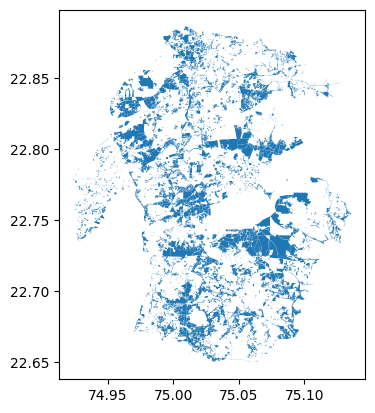

In [13]:
# ISOLATE AREA ONLY - select rows that have a number as their Name
dhar_yellow_shapes_gdf = dhar_gdf[dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_yellow_shapes_gdf.plot()

<Axes: >

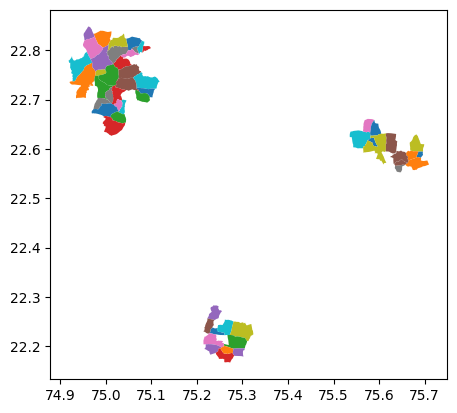

In [14]:
# ISOLATE VILLAGES ONLY - select rows that have a string as their Name
dhar_village_shapes_gdf = dhar_gdf[~dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_village_shapes_gdf = dhar_village_shapes_gdf.drop(columns="cleaned_name")
dhar_village_shapes_gdf = dhar_village_shapes_gdf.rename(
    columns={"Name": "village_name"}
)
dhar_village_shapes_gdf.plot(column="village_name")

Missing village name: 2394
Has village name: 4905


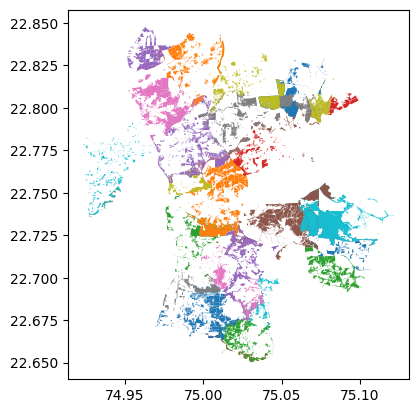

In [15]:
# add village names to areas
dhar_processed_areas_gdf = dhar_yellow_shapes_gdf.sjoin(
    dhar_village_shapes_gdf, how="left", predicate="intersects"
).drop(columns="index_right")
dhar_processed_areas_gdf.plot(column="village_name")
print("Missing village name:", dhar_processed_areas_gdf["village_name"].isnull().sum())
print("Has village name:", dhar_processed_areas_gdf["village_name"].notnull().sum())

In [16]:
# Apply the function to the khasra_id column
dhar_processed_areas_gdf["khasra_id"] = dhar_processed_areas_gdf["Name"]
dhar_processed_areas_gdf["khasra_id"] = add_suffix_to_duplicates(
    dhar_processed_areas_gdf["khasra_id"]
)

In [17]:
dhar_processed_areas_gdf.drop(columns="cleaned_name", inplace=True)

In [37]:
# shift shapes by 100km to the left and mirror them across the vertical axis to jumble the shapes for privacy. Also drop 20% of the shapes randomly.
dhar_processed_areas_gdf_private = dhar_processed_areas_gdf.copy()
dhar_processed_areas_gdf_private["geometry"] = dhar_processed_areas_gdf_private["geometry"].translate(
    xoff=-1
)
# Mirror across a common origin (centroid of all shapes) to actually flip the distribution
common_centroid = dhar_processed_areas_gdf_private.unary_union.centroid
dhar_processed_areas_gdf_private["geometry"] = dhar_processed_areas_gdf_private["geometry"].scale(xfact=-1, yfact=-1, origin=common_centroid)
dhar_processed_areas_gdf_private = dhar_processed_areas_gdf_private.sample(frac=0.8, random_state=42).reset_index(drop=True)

<Axes: >

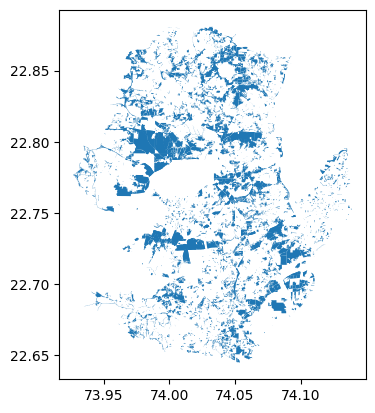

In [38]:
dhar_processed_areas_gdf_private.plot()

In [39]:
# save to file
save_shapefiles(
    dhar_processed_areas_gdf_private,
    PROCESSED_DATA_DIR,
    "example_khasras",
    formats=["kml", "parquet"],
)

In [ ]:
# save to file
save_shapefiles(
    dhar_processed_areas_gdf,
    PROCESSED_DATA_DIR / "Dhar" / "dhar_cleaned_khasras",
    "dhar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Sagar

In [ ]:
gdfs = []

for filename in ["sagar_khamkuwa", "sagar_mokalpur", "sagar_tekapar"]:
    gdf = gpd.read_file(
        RAW_DATA_DIR / "solar_park_shapefiles" / "Sagar Khasras" / f"{filename}.kml",
        driver="KML",
    )
    gdf["source"] = filename
    gdfs.append(gdf)

raw_sagar_gdf = pd.concat(gdfs, ignore_index=True)

In [ ]:
# remove z-dimension
raw_sagar_gdf.geometry = raw_sagar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
raw_sagar_gdf = raw_sagar_gdf.explode(column="geometry", ignore_index=True)
raw_sagar_gdf.plot(column="source", legend=True)

In [ ]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_sagar_gdf)
raw_sagar_gdf.drop(columns=["Name", "Description"], inplace=True)
sagar_gdf = raw_sagar_gdf.merge(df_vars, left_index=True, right_index=True)

In [ ]:
sagar_gdf.plot(column="PAR_TYPE")

In [ ]:
sagar_gdf["village_name"] = sagar_gdf["source"].str.split("_").str[1]
sagar_gdf["source"] = sagar_gdf["source"].str.split("_").str[0]

In [ ]:
# sagar_gdf["khasra_id"] = "SAGAR_" + sagar_gdf["UNQID"]
sagar_gdf["khasra_id"] = sagar_gdf["village_name"] + "_" + sagar_gdf["KID"]
sagar_gdf["khasra_id"] = add_suffix_to_duplicates(sagar_gdf["khasra_id"])

In [ ]:
save_shapefiles(
    sagar_gdf,
    PROCESSED_DATA_DIR / "Sagar" / "sagar_cleaned_khasras",
    "sagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Ashok Nagar

In [ ]:
gdf = gpd.read_file(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Ashok Nagar Khasras"
    / "Ashok_nagar_khasras.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
gdf.geometry = gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [ ]:
gdf

In [ ]:
gdf.plot(column="Name", legend=True)

In [ ]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(gdf)
gdf.drop(columns=["Name", "Description"], inplace=True)
gdf_merged = gdf.merge(df_vars, left_index=True, right_index=True)

In [ ]:
gdf_merged.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
        "khasra_no": "Name",
        "Patch_Name": "parcel_id",
    },
    inplace=True,
)

In [ ]:
save_shapefiles(
    gdf_merged,
    PROCESSED_DATA_DIR / "Ashok Nagar" / "ashok_nagar_cleaned_khasras",
    "ashok_nagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Shivpuri

In [ ]:
raw_shivpuri_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Shivpuri Khasras" / "Shivpuri_khasra.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
raw_shivpuri_gdf.geometry = raw_shivpuri_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [ ]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_shivpuri_gdf)
raw_shivpuri_gdf.drop(columns=["Name", "Description"], inplace=True)
shivpuri_gdf = raw_shivpuri_gdf.merge(df_vars, left_index=True, right_index=True)

In [ ]:
shivpuri_gdf.plot(column="Patch_Name")

In [ ]:
shivpuri_gdf.plot(column="Cluster", legend=True)

In [ ]:
shivpuri_gdf

In [ ]:
shivpuri_gdf.columns

In [ ]:
shivpuri_gdf.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
    },
    inplace=True,
)

In [ ]:
save_shapefiles(
    shivpuri_gdf,
    PROCESSED_DATA_DIR / "Shivpuri" / "shivpuri_cleaned_khasras",
    "shivpuri_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Morena

In [ ]:
import re


def parse_morena_description_col_to_dict(desc):
    # Remove leading text before first <B> tag
    desc = re.sub(r"^.*?<B>", "<B>", desc, flags=re.DOTALL)
    # Find all <B>key</B> = value<BR> pairs
    matches = re.findall(r"<B>([^<]+)</B>\s*=\s*(.*?)<BR>", desc)
    # Build dictionary
    result = {k.strip(): v.strip() for k, v in matches}

    return result


def get_morena_description_as_df(description_series: pd.Series) -> pd.DataFrame:
    # Apply the function to the Description column
    df_description_dict_list = description_series.apply(
        parse_morena_description_col_to_dict
    ).tolist()
    df_vars = pd.DataFrame(df_description_dict_list, index=description_series.index)

    return df_vars

#### Vijaypur sub-area

In [ ]:
raw_vijaypur_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "vijaypur_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_vijaypur_gdf = raw_vijaypur_gdf[
    ~raw_vijaypur_gdf["Name"].str.contains("Vijaypur|SEO", case=False, na=False)
]
filtered_vijaypur_gdf["Source"] = "Vijaypur Khasras"
filtered_vijaypur_gdf["Tehsil Name"] = "Vijaypur"

In [ ]:
# # OLD - pull patch name out of the description
# filtered_vijaypur_gdf["Patch Name"] = filtered_vijaypur_gdf["Description"].str.extract(
#     r"patch_name</B> = (.+?)<BR>"
# )

# apply the function to the Description column
vijaypur_desc_vars_df = get_morena_description_as_df(
    filtered_vijaypur_gdf["Description"]
)
filtered_vijaypur_gdf = filtered_vijaypur_gdf.merge(
    vijaypur_desc_vars_df, left_index=True, right_index=True
)
filtered_vijaypur_gdf.drop(columns="Description", inplace=True)

In [ ]:
cols_to_keep = [
    "Name",
    "geometry",
    "Source",
    "patch_name",
    # "patch_area",
    # "ID",
    # "DISTRICTC",
    "Tehsil Name",
    "TEHSILCODE",
    # "LGDGPCODE",
    # "CCODE11",
    # "VILLAGEH",
    "VILLAGEE",
    "BHUCODE",
    # "KHASRA_NO",
    # "KHASRA_ARE",
    # "OWNERNAME",
    # "COLUMN12IN",
    "NOIYAT",
    # "LANDTYPE",
    # "FEATUREID",
    # "DIST_CD",
    "ROR_kid",
    # "ROR_AREA",
    # "UID_AREA",
    # "LGDCD",
]
cols_rename = {
    "Name": "Khasra ID",
    "patch_name": "Patch Name",
    "TEHSILCODE": "Tehsil Code",
    "VILLAGEE": "Village Name",
    "BHUCODE": "BHU Code",
    "NOIYAT": "Noiyat",
    "ROR_kid": "ROR KID",
}

filtered_vijaypur_gdf = filtered_vijaypur_gdf[cols_to_keep]
filtered_vijaypur_gdf.rename(columns=cols_rename, inplace=True)

In [ ]:
filtered_vijaypur_gdf

#### Joura sub-area

In [ ]:
raw_joura_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "joura_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_joura_gdf = raw_joura_gdf[
    ~raw_joura_gdf["Name"].str.contains("Joura|MRA", case=False, na=False)
]
filtered_joura_gdf["Source"] = "Joura Khasras"
filtered_joura_gdf["Tehsil Name"] = "Joura"

In [ ]:
# # OLD - pull patch name out of the description
# filtered_joura_gdf["Patch Name"] = filtered_joura_gdf["Description"].str.extract(
#     r"patch_name</B> = (.+?)<BR>"
# )

# apply the function to the Description column
joura_desc_vars_df = get_morena_description_as_df(filtered_joura_gdf["Description"])
filtered_joura_gdf = filtered_joura_gdf.merge(
    joura_desc_vars_df, left_index=True, right_index=True
)
filtered_joura_gdf.drop(columns="Description", inplace=True)

In [ ]:
filtered_joura_gdf = filtered_joura_gdf[cols_to_keep]
filtered_joura_gdf.rename(columns=cols_rename, inplace=True)

In [ ]:
filtered_joura_gdf

#### Solar park boundary

In [ ]:
raw_solar_park_boundary_gdf = gpd.read_file(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "solar_park_boundary.kml",
    driver="KML",
)
raw_solar_park_boundary_gdf["Source"] = "Solar Park Boundary"

In [ ]:
# find <td>FID</td> <td>10</td> and store the value in "Patch Name" variable
raw_solar_park_boundary_gdf["Village Name"] = raw_solar_park_boundary_gdf[
    "Description"
].str.extract(r"<td>FID</td>\s*<td>(\d+)</td>")
raw_solar_park_boundary_gdf["Patch Name"] = raw_solar_park_boundary_gdf["Village Name"]
raw_solar_park_boundary_gdf.drop(columns="Description", inplace=True)

In [ ]:
raw_solar_park_boundary_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)

#### Combine and clean

In [ ]:
# combine into one gdf
morena_gdf = pd.concat(
    [
        filtered_joura_gdf,
        filtered_vijaypur_gdf,
        raw_solar_park_boundary_gdf,
    ],
    ignore_index=True,
)

In [ ]:
morena_gdf.shape

In [ ]:
morena_gdf.plot(column="Source", legend=True)

In [ ]:
# remove z-dimension
morena_gdf.geometry = morena_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
morena_gdf_clean = morena_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
morena_gdf_clean = morena_gdf_clean[
    morena_gdf_clean.geometry.type.isin(["Polygon", "MultiPolygon"])
]

In [ ]:
len(morena_gdf_clean) == len(morena_gdf)

In [ ]:
morena_gdf_clean = morena_gdf_clean.drop_duplicates(subset=["geometry"])
morena_gdf_clean.shape

In [ ]:
morena_gdf_clean["Khasra ID (Unique)"] = (
    morena_gdf_clean["Khasra ID"].astype(str)
    + " ("
    + morena_gdf_clean["Village Name"].astype(str)
    + ")"
)

In [ ]:
morena_gdf_clean["Khasra ID (Unique)"].nunique()

In [ ]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = morena_gdf_clean[
    morena_gdf_clean["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))
for khasra_id in tqdm(duplicated_khasraID_list):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        DATA_DIR
        / "01_processed"
        / "Solar Parks"
        / "Morena 2"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

Ok, so it seems like these are khasra fragments. Merge them into one khasra, combining their shapes.

In [ ]:
morena_gdf_dissolved = morena_gdf_clean.dissolve(by="Khasra ID (Unique)").reset_index()

# alternatively, add a suffix to get each fragment separately
# morena_gdf_clean["Khasra ID (Unique)"] = add_suffix_to_duplicates(morena_gdf_clean["Khasra ID (Unique)"])

#### Load Noiyat allocations and match

In [ ]:
joura_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "Noiyat Files"
    / "teshil_joura_5HA_patch_identity.xlsx",
    sheet_name="identity_category",
)

vijaypur_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "Noiyat Files"
    / "Vijaypur_5ha_Identity&Patch.xlsx",
    sheet_name="Sheopur_Identity_Category",
)
vijaypur_lookup.rename(
    columns={"category": "Category"},
    inplace=True,
)

In [ ]:
barwani_khasra_gdf_dissolved = pd.concat(
    [joura_lookup, vijaypur_lookup], ignore_index=True
)
barwani_khasra_gdf_dissolved = barwani_khasra_gdf_dissolved.sort_values(
    by=["villagee", "kid_geometry"]
)
barwani_khasra_gdf_dissolved["Category"] = barwani_khasra_gdf_dissolved[
    "Category"
].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
barwani_khasra_gdf_dissolved["Khasra ID (Unique)"] = (
    barwani_khasra_gdf_dissolved["kid_geometry"].astype(str)
    + " ("
    + barwani_khasra_gdf_dissolved["villagee"].astype(str)
    + ")"
)

In [ ]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = barwani_khasra_gdf_dissolved.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

In [ ]:
morena_gdf_merged = morena_gdf_dissolved.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
morena_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

morena_gdf_merged

In [ ]:
# Calculate original areas
morena_gdf_merged["Original Area (ha)"] = (
    morena_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [ ]:
# add % unusable area
morena_gdf_merged["Noiyat Unusable Area (%)"] = (
    morena_gdf_merged["Noiyat Unusable Area (ha)"]
    / morena_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
morena_gdf_merged["Noiyat Unusable Area (%)"] = morena_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

In [ ]:
morena_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

In [ ]:
# morena_gdf_merged[(morena_gdf_merged["Noiyat % Unusable Area"] > 80) & (morena_gdf_merged["Noiyat % Unusable Area"] < 100)]
morena_gdf_merged

In [ ]:
save_shapefiles(
    morena_gdf_merged,
    DATA_DIR
    / "01_processed"
    / "Solar Parks"
    / "Morena 2"
    / "01 Processed Data"
    / "Cleaned Khasras",
    "morena_cleaned_khasras",
    formats=["kml", "parquet", "csv"],
)

### Barwani

In [ ]:
barwani_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Barwani Khasras" / "barwani_khasras.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
barwani_gdf.geometry = barwani_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
barwani_gdf = barwani_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
barwani_gdf = barwani_gdf[barwani_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

In [ ]:
barwani_gdf.plot()

In [ ]:
barwani_gdf

In [ ]:
# no info in Description
barwani_gdf.drop(columns=["Description"], inplace=True)

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [ ]:
# the Name column has names like BWI20,21.382ha for patches and others are khasras
# separate those who start with BWI
barwani_patches_gdf = barwani_gdf[barwani_gdf["Name"].str.startswith("BWI")]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(",").str[0]
barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
barwani_patches_gdf

In [ ]:
# khasras
barwani_khasra_gdf = barwani_gdf[~barwani_gdf["Name"].str.startswith("BWI")]
barwani_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
barwani_khasra_gdf

In [ ]:
len(barwani_khasra_gdf) + len(barwani_patches_gdf) == len(barwani_gdf)

In [ ]:
barwani_khasra_gdf = barwani_khasra_gdf.sjoin(
    barwani_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
barwani_khasra_gdf = barwani_khasra_gdf[
    ~barwani_khasra_gdf.index.duplicated(keep="first")
]

In [ ]:
barwani_khasra_gdf["Patch Name"].isnull().sum()

In [ ]:
barwani_khasra_gdf

#### Add unique ID column (Khasra ID is not unique across the dataset)

In [ ]:
barwani_khasra_gdf["Khasra ID"].duplicated().sum()

In [ ]:
barwani_khasra_gdf["Khasra ID (Unique)"] = (
    barwani_khasra_gdf["Khasra ID"] + " (" + barwani_khasra_gdf["Patch Name"] + ")"
)

In [ ]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = barwani_khasra_gdf[
    barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

In [ ]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / "Barwani"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

In [ ]:
# looks like all duplicates are shards of a single real khasra - combine them here
barwani_khasra_gdf_dissolved = barwani_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

# # ALTERNATIVE - if there are duplicates, add a suffix
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID"].astype(str)
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID (Unique)"].where(
#     ~barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False),
#     barwani_khasra_gdf["Khasra ID (Unique)"]
#     + "_part_"
#     + (barwani_khasra_gdf.groupby("Khasra ID (Unique)").cumcount() + 1).astype(str),
# )

In [ ]:
barwani_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

In [ ]:
barwani_khasra_gdf_dissolved[
    barwani_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

#### Load Noiyat allocations and match

In [ ]:
barwani_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Barwani Khasras"
    / "Barvani_20ha_patch_khasra140725_RR.xlsx",
    sheet_name="noiyat_category",
)

In [ ]:
barwani_lookup.columns

In [ ]:
barwani_lookup = barwani_lookup.sort_values(by=["VILLAGEE", "KHASRA_NO"])
barwani_lookup["Category"] = barwani_lookup["Category"].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
barwani_lookup["Khasra ID (Unique)"] = (
    barwani_lookup["KHASRA_NO"].astype(str)
    + " ("
    + barwani_lookup["patch_name"].astype(str)
    + ")"
)

In [ ]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = barwani_lookup.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

In [ ]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_dissolved.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

barwani_khasra_gdf_merged

In [ ]:
deduped_barwani_lookup = barwani_lookup.drop_duplicates(subset=["Khasra ID (Unique)"])[
    ["Khasra ID (Unique)", "TEHSILCODE", "VILLAGEE", "BHUCODE", "noiyat", "ROR_kid"]
]
deduped_barwani_lookup.rename(
    columns={
        "TEHSILCODE": "Tehsil Code",
        "VILLAGEE": "Village Name",
        "BHUCODE": "BHU Code",
        "noiyat": "Noiyat",
        "ROR_kid": "ROR KID",
    },
    inplace=True,
)

barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.merge(
    deduped_barwani_lookup,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged

In [ ]:
barwani_khasra_gdf_merged.plot(column="Village Name")

In [ ]:
# Calculate original areas
barwani_khasra_gdf_merged["Original Area (ha)"] = (
    barwani_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [ ]:
# add % unusable area
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = (
    barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"]
    / barwani_khasra_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = barwani_khasra_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

In [ ]:
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

#### Cleanup and save

In [ ]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)

In [ ]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_merged[
    [
        "Khasra ID (Unique)",
        "Tehsil Code",
        "Village Name",
        "BHU Code",
        "Noiyat",
        "ROR KID",
        "Patch Name",
        "Khasra ID",
        "Original Area (ha)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    barwani_khasra_gdf_merged,
    PROCESSED_DATA_DIR / "Barwani" / "01 Processed Data" / "Cleaned Khasras",
    "barwani_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Betul

In [ ]:
betul_gdf_1 = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Betul Khasras" / "betul_khasras.kml",
    driver="KML",
)

In [ ]:
betul_gdf_2 = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Betul Khasras" / "betul_khasras_2.kml",
    driver="KML",
)
# drop substations
betul_gdf_2 = betul_gdf_2[~betul_gdf_2["Name"].isin(["Birolijhilpa", "Gadara", "Somegarh"])]

In [ ]:
barwani_gdf = pd.concat([betul_gdf_1, betul_gdf_2], ignore_index=True) # need to rename

In [ ]:
# remove z-dimension
barwani_gdf.geometry = barwani_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
barwani_gdf = barwani_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
barwani_gdf = barwani_gdf[barwani_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

In [ ]:
barwani_gdf = barwani_gdf[barwani_gdf["Name"] != ""]

In [ ]:
barwani_gdf.plot()

In [ ]:
barwani_gdf

In [ ]:
# no info in Description
barwani_gdf.drop(columns=["Description"], inplace=True)

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [ ]:
# the Name column has names like BZU1 for patches and others are khasras
# separate those who start with BZU
barwani_patches_gdf = barwani_gdf[barwani_gdf["Name"].str.startswith("BZU")]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(",").str[0]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(" ").str[0]
barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
barwani_patches_gdf

In [ ]:
# khasras
barwani_khasra_gdf = barwani_gdf[~barwani_gdf["Name"].str.startswith("BZU")]
barwani_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
barwani_khasra_gdf

In [ ]:
len(barwani_khasra_gdf) + len(barwani_patches_gdf) == len(barwani_gdf)

In [ ]:
barwani_khasra_gdf = barwani_khasra_gdf.sjoin(
    barwani_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
barwani_khasra_gdf = barwani_khasra_gdf[
    ~barwani_khasra_gdf.index.duplicated(keep="first")
]

In [ ]:
barwani_khasra_gdf["Patch Name"].isnull().sum()

In [ ]:
barwani_khasra_gdf

#### Add unique ID column (Khasra ID is not unique across the dataset)

In [ ]:
barwani_khasra_gdf["Khasra ID"].duplicated().sum()

In [ ]:
barwani_khasra_gdf["Khasra ID (Unique)"] = (
    barwani_khasra_gdf["Khasra ID"] + " (" + barwani_khasra_gdf["Patch Name"] + ")"
)

In [ ]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = barwani_khasra_gdf[
    barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

In [ ]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / "Betul"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

In [ ]:
# looks like all duplicates are shards of a single real khasra - combine them here
barwani_khasra_gdf_dissolved = barwani_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

# # ALTERNATIVE - if there are duplicates, add a suffix
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID"].astype(str)
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID (Unique)"].where(
#     ~barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False),
#     barwani_khasra_gdf["Khasra ID (Unique)"]
#     + "_part_"
#     + (barwani_khasra_gdf.groupby("Khasra ID (Unique)").cumcount() + 1).astype(str),
# )

In [ ]:
barwani_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

In [ ]:
barwani_khasra_gdf_dissolved[
    barwani_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

In [ ]:
barwani_khasra_gdf_dissolved = barwani_khasra_gdf_dissolved.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)
# Calculate original areas
barwani_khasra_gdf_dissolved["Original Area (ha)"] = (
    barwani_khasra_gdf_dissolved.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [ ]:
barwani_khasra_gdf_dissolved

In [ ]:
barwani_khasra_gdf_dissolved

In [ ]:
barwani_khasra_gdf_dissolved = barwani_khasra_gdf_dissolved[
    [
        "Khasra ID (Unique)",
        "Patch Name",
        "Khasra ID",
        "Original Area (ha)",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    barwani_khasra_gdf_dissolved,
    PROCESSED_DATA_DIR / "Betul" / "01 Processed Data" / "Cleaned Khasras",
    "betul_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Damoh

In [8]:
LOCATION = "Damoh"

In [9]:
# KMZ files are zipped KML files - use /vsizip/ prefix to read them
kmz_path = RAW_DATA_DIR / "solar_park_shapefiles" / "Damoh Khasras" / "selecteddamoh030126.kmz"
damoh_gdf = gpd.read_file(f"/vsizip/{kmz_path}/doc.kml")

In [10]:
damoh_gdf

,Name,Description,geometry
0,66,Unknown Area Type,GEOMETRYCOLLECTION Z (POINT Z (79.20199 23.240...
1,59,Unknown Area Type,GEOMETRYCOLLECTION Z (POINT Z (79.19895 23.244...
2,69,Unknown Area Type,GEOMETRYCOLLECTION Z (POINT Z (79.20549 23.241...
3,46,Unknown Area Type,GEOMETRYCOLLECTION Z (POINT Z (79.19600 23.247...
4,45,Unknown Area Type,GEOMETRYCOLLECTION Z (POINT Z (79.19261 23.247...
...,...,...,...
5991,39 Ha,,POINT Z (79.49231 24.23464 0.00000)
5992,244,,POINT Z (79.47933 24.22662 0.00000)
5993,58 Ha,,POINT Z (79.46633 24.23981 0.00000)
5994,107 Ha,,POINT Z (79.45829 24.23547 0.00000)


In [11]:
# remove z-dimension
damoh_gdf.geometry = damoh_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
damoh_gdf = damoh_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
damoh_gdf = damoh_gdf[damoh_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

<Axes: >

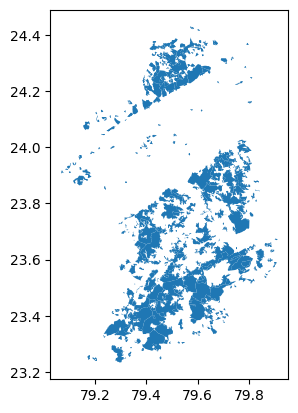

In [12]:
damoh_gdf.plot()

In [13]:
# there is no info in Description, drop it
damoh_gdf.drop(columns=["Description"], inplace=True)

In [14]:
# drop all rows with null or empty string in Name column
damoh_gdf = damoh_gdf[damoh_gdf["Name"].notnull() & (damoh_gdf["Name"] != "")]

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [15]:
# the Name column has names like BWI20,21.382ha for patches and others are khasras
# separate those who start with BWI
damoh_patches_gdf = damoh_gdf[damoh_gdf["Name"].str.startswith("DMO")]
damoh_patches_gdf["Name"] = damoh_patches_gdf["Name"].str.split(",").str[0]
damoh_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
damoh_patches_gdf

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_11625/2481714937.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  damoh_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)


,Patch Name,geometry
10785,DMO16,"POLYGON ((79.19466 23.24627, 79.19454 23.24631..."
10787,DMO17,"POLYGON ((79.20131 23.24615, 79.20103 23.24629..."
10789,DMO18,"POLYGON ((79.20131 23.24615, 79.20153 23.24612..."
10791,DMO19,"POLYGON ((79.17989 23.24711, 79.17992 23.24751..."
10793,DMO22,"POLYGON ((79.18094 23.25884, 79.18090 23.25884..."
...,...,...
11389,DMO3495,"POLYGON ((79.61060 24.37988, 79.61021 24.38000..."
11391,DMO3498,"POLYGON ((79.66798 24.38072, 79.66793 24.38078..."
11393,DMO3499,"POLYGON ((79.51343 24.38702, 79.51327 24.38706..."
11395,DMO3519,"POLYGON ((79.60393 24.41950, 79.60395 24.41958..."


In [16]:
# khasras
damoh_khasra_gdf = damoh_gdf[~damoh_gdf["Name"].str.startswith("DMO")]
damoh_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
damoh_khasra_gdf

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_11625/3373298530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  damoh_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)


,Khasra ID,geometry
1,66,"POLYGON ((79.20316 23.23974, 79.20318 23.24018..."
3,59,"POLYGON ((79.19967 23.24201, 79.19985 23.24242..."
5,69,"POLYGON ((79.20316 23.23974, 79.20325 23.23975..."
7,46,"POLYGON ((79.20131 23.24615, 79.20103 23.24629..."
9,45,"POLYGON ((79.19302 23.24890, 79.19300 23.24891..."
...,...,...
10775,203,"POLYGON ((79.51416 24.38342, 79.51405 24.38357..."
10777,203,"POLYGON ((79.51500 24.38275, 79.51504 24.38277..."
10779,206,"POLYGON ((79.51477 24.38205, 79.51492 24.38205..."
10781,203,"POLYGON ((79.51477 24.38205, 79.51492 24.38205..."


In [17]:
len(damoh_khasra_gdf) + len(damoh_patches_gdf) == len(damoh_gdf)

True

In [18]:
damoh_khasra_gdf = damoh_khasra_gdf.sjoin(
    damoh_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
damoh_khasra_gdf = damoh_khasra_gdf[
    ~damoh_khasra_gdf.index.duplicated(keep="first")
]

In [19]:
damoh_khasra_gdf["Patch Name"].isnull().sum()

0

<Axes: >

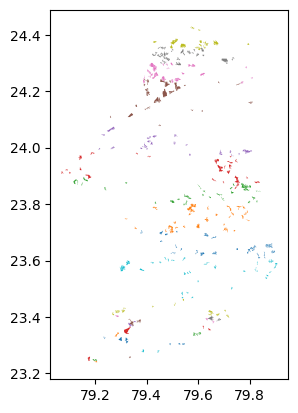

In [20]:
damoh_khasra_gdf.plot(column="Patch Name")

#### Add unique ID column (Khasra ID is not unique across the dataset)

In [21]:
damoh_khasra_gdf["Khasra ID"].duplicated().sum()

4524

In [22]:
damoh_khasra_gdf["Khasra ID (Unique)"] = (
    damoh_khasra_gdf["Khasra ID"] + " (" + damoh_khasra_gdf["Patch Name"] + ")"
)

In [23]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = damoh_khasra_gdf[
    damoh_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

Number of duplicated Khasra IDs: 729


In [24]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / LOCATION
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

  0%|          | 0/100 [00:00<?, ?it/s]

In [25]:
# looks like all duplicates are shards of a single real khasra - combine them here
damoh_khasra_gdf_dissolved = damoh_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

# # ALTERNATIVE - if there are duplicates, add a suffix
# damoh_khasra_gdf["Khasra ID (Unique)"] = damoh_khasra_gdf["Khasra ID"].astype(str)
# damoh_khasra_gdf["Khasra ID (Unique)"] = damoh_khasra_gdf["Khasra ID (Unique)"].where(
#     ~damoh_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False),
#     damoh_khasra_gdf["Khasra ID (Unique)"]
#     + "_part_"
#     + (damoh_khasra_gdf.groupby("Khasra ID (Unique)").cumcount() + 1).astype(str),
# )

In [26]:
damoh_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

0

In [27]:
damoh_khasra_gdf_dissolved[
    damoh_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

,Khasra ID (Unique),geometry,Khasra ID,Patch Name


#### Load Noiyat allocations and match

In [28]:
# barwani_lookup = pd.read_excel(
#     RAW_DATA_DIR
#     / "solar_park_shapefiles"
#     / "Barwani Khasras"
#     / "Barvani_20ha_patch_khasra140725_RR.xlsx",
#     sheet_name="noiyat_category",
# )

In [29]:
# barwani_lookup.columns

In [30]:
# barwani_lookup = barwani_lookup.sort_values(by=["VILLAGEE", "KHASRA_NO"])
# barwani_lookup["Category"] = barwani_lookup["Category"].replace(
#     {
#         "To be considered for allotment": "Usable",
#         # "Unusable": "Unusable", # already labeled as Unusable
#     }
# )
# barwani_lookup["Khasra ID (Unique)"] = (
#     barwani_lookup["KHASRA_NO"].astype(str)
#     + " ("
#     + barwani_lookup["patch_name"].astype(str)
#     + ")"
# )

In [31]:
# # Pivot the data to get usable/unusable areas per khasra
# pivot_df = barwani_lookup.pivot_table(
#     index="Khasra ID (Unique)",
#     columns="Category",
#     values="land_size_noiyat",
#     aggfunc="sum",
#     fill_value=0,
# ).reset_index()
# pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
# pivot_df.rename(
#     columns={
#         "Unusable": "Noiyat Unusable Area (ha)",
#     },
#     inplace=True,
# )
# pivot_df

In [32]:
# barwani_khasra_gdf_merged = barwani_khasra_gdf_dissolved.merge(
#     pivot_df,
#     on="Khasra ID (Unique)",
#     how="left",
# )
# barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

# barwani_khasra_gdf_merged

In [33]:
# deduped_barwani_lookup = barwani_lookup.drop_duplicates(subset=["Khasra ID (Unique)"])[
#     ["Khasra ID (Unique)", "TEHSILCODE", "VILLAGEE", "BHUCODE", "noiyat", "ROR_kid"]
# ]
# deduped_barwani_lookup.rename(
#     columns={
#         "TEHSILCODE": "Tehsil Code",
#         "VILLAGEE": "Village Name",
#         "BHUCODE": "BHU Code",
#         "noiyat": "Noiyat",
#         "ROR_kid": "ROR KID",
#     },
#     inplace=True,
# )

# barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.merge(
#     deduped_barwani_lookup,
#     on="Khasra ID (Unique)",
#     how="left",
# )
# barwani_khasra_gdf_merged

In [34]:
# barwani_khasra_gdf_merged.plot(column="Village Name")

In [35]:
# # Calculate original areas
# barwani_khasra_gdf_merged["Original Area (ha)"] = (
#     barwani_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
# )

In [36]:
# # add % unusable area
# barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = (
#     barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"]
#     / barwani_khasra_gdf_merged["Original Area (ha)"]
#     * 100
# ).round(2)

# # set max to 100 and min to 0 for any weird values
# barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = barwani_khasra_gdf_merged[
#     "Noiyat Unusable Area (%)"
# ].clip(0, 100)

In [37]:
# barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

#### Cleanup and save

In [38]:
damoh_khasra_gdf_dissolved = damoh_khasra_gdf_dissolved.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)

In [39]:
damoh_khasra_gdf_dissolved = damoh_khasra_gdf_dissolved[
    [
        "Khasra ID (Unique)",
        "Patch Name",
        "Khasra ID",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    damoh_khasra_gdf_dissolved,
    PROCESSED_DATA_DIR / LOCATION / "01 Processed Data" / "Cleaned Khasras",
    "damoh_cleaned_khasras",
    formats=["kml", "parquet"],
)

#### Filter to patches of interest

<Axes: >

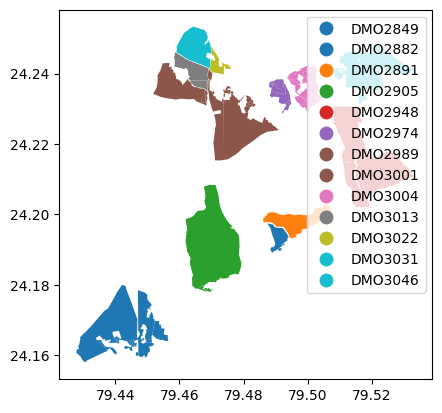

In [50]:
damoh_khasra_gdf_selected_patches = damoh_khasra_gdf_dissolved[
    damoh_khasra_gdf_dissolved["Patch Name"].isin(
        [
            "DMO2849",
            "DMO2905",
            "DMO2882",
            "DMO2891",
            "DMO2948",
            "DMO3004",
            "DMO2974",
            "DMO2989",
            "DMO3001",
            "DMO3013",
            "DMO3046",
            "DMO3031",
            "DMO3022",
        ]
    )
]

damoh_khasra_gdf_selected_patches.plot(column="Patch Name", legend=True)

In [51]:
save_shapefiles(
    damoh_khasra_gdf_selected_patches,
    PROCESSED_DATA_DIR / LOCATION / "01 Processed Data" / "Cleaned Khasras",
    "damoh_cleaned_khasras_selected_patches",
    formats=["kml", "parquet"],
)

### Alirajpur

In [8]:
alirajpur_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Alirajpur Khasras" / "doc.kml",
    driver="KML",
)

In [9]:
# remove z-dimension
alirajpur_gdf.geometry = alirajpur_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
alirajpur_gdf = alirajpur_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
alirajpur_gdf = alirajpur_gdf[alirajpur_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

In [10]:
# no info in Description
alirajpur_gdf.drop(columns=["Description"], inplace=True)

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [28]:
# the Name column has names like 30.444 ARPR516 for patches and others are khasras
# separate those that have ARPR in the name
alirajpur_patches_gdf = alirajpur_gdf[alirajpur_gdf["Name"].str.contains("ARPR")]
alirajpur_patches_gdf["Name"] = alirajpur_patches_gdf["Name"].str.split(" ").str[1]
alirajpur_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
alirajpur_patches_gdf

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_96770/1195661368.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alirajpur_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)


,Patch Name,geometry
1448,ARPR12,"POLYGON ((74.26319 21.98347, 74.26318 21.98346..."
1450,ARPR25,"POLYGON ((74.21429 21.99081, 74.21433 21.99084..."
1452,ARPR26,"POLYGON ((74.20598 21.99324, 74.20634 21.99330..."
1454,ARPR34,"POLYGON ((74.18137 21.99831, 74.18122 21.99836..."
1456,ARPR36,"POLYGON ((74.18796 21.99879, 74.18797 21.99883..."
...,...,...
3528,ARPR4670,"POLYGON ((74.39228 22.60282, 74.39206 22.60283..."
3530,ARPR4678,"POLYGON ((74.36996 22.60826, 74.36990 22.60832..."
3532,ARPR4680,"POLYGON ((74.38114 22.61072, 74.38106 22.61080..."
3534,ARPR4682,"POLYGON ((74.40302 22.61474, 74.40299 22.61475..."


In [29]:
# get tehsils
alirajpur_tehsil_gdf = alirajpur_gdf[
    ~ alirajpur_gdf["Name"].str.contains(r"\d", na=False)
    & alirajpur_gdf["Name"].notna()
    & (alirajpur_gdf["Name"].str.strip() != "")
]
alirajpur_tehsil_gdf.rename(columns={"Name": "Tehsil Name"}, inplace=True)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_96770/2024228106.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alirajpur_tehsil_gdf.rename(columns={"Name": "Tehsil Name"}, inplace=True)


In [36]:
# khasras - drop any rows which match ARPR somewhere, contain no numbers, or are blank in Name
alirajpur_khasra_gdf = alirajpur_gdf[
    ~alirajpur_gdf["Name"].str.contains("ARPR", case=False, na=False)
    & alirajpur_gdf["Name"].str.contains(r"\d", na=False)
    & alirajpur_gdf["Name"].notna()
    & (alirajpur_gdf["Name"].str.strip() != "")
]
alirajpur_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
alirajpur_khasra_gdf

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_96770/548506478.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alirajpur_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)


,Khasra ID,geometry
3538,27,"POLYGON ((74.26319 21.98347, 74.26318 21.98346..."
3540,236,"POLYGON ((74.20688 21.99098, 74.20689 21.99102..."
3542,237,"POLYGON ((74.20684 21.99057, 74.20684 21.99083..."
3544,410,"POLYGON ((74.21165 21.99065, 74.21155 21.99074..."
3546,363,"POLYGON ((74.20857 21.99091, 74.20838 21.99092..."
...,...,...
40754,410,"POLYGON ((74.29367 22.13049, 74.29368 22.13051..."
40756,411,"POLYGON ((74.29367 22.13049, 74.29368 22.13051..."
40758,341,"POLYGON ((74.27482 22.17989, 74.27482 22.17990..."
40760,1,"POLYGON ((74.27482 22.17989, 74.27482 22.17990..."


In [37]:
len(alirajpur_khasra_gdf) + len(alirajpur_patches_gdf) + len(
    alirajpur_gdf[~alirajpur_gdf["Name"].str.contains(r"\d", na=False)]
) == len(alirajpur_gdf)

True

In [38]:
# add in Patch Name
alirajpur_khasra_gdf = alirajpur_khasra_gdf.sjoin(
    alirajpur_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
alirajpur_khasra_gdf = alirajpur_khasra_gdf[
    ~alirajpur_khasra_gdf.index.duplicated(keep="first")
]

# add in Tehsil Name
alirajpur_khasra_gdf = alirajpur_khasra_gdf.sjoin(
    alirajpur_tehsil_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
alirajpur_khasra_gdf = alirajpur_khasra_gdf[
    ~alirajpur_khasra_gdf.index.duplicated(keep="first")
]

In [39]:
alirajpur_khasra_gdf

,Khasra ID,geometry,Patch Name,Tehsil Name
3538,27,"POLYGON ((74.26319 21.98347, 74.26318 21.98346...",ARPR12,Khundi
3540,236,"POLYGON ((74.20688 21.99098, 74.20689 21.99102...",ARPR25,Wakner
3542,237,"POLYGON ((74.20684 21.99057, 74.20684 21.99083...",ARPR25,Wakner
3544,410,"POLYGON ((74.21165 21.99065, 74.21155 21.99074...",ARPR25,Wakner
3546,363,"POLYGON ((74.20857 21.99091, 74.20838 21.99092...",ARPR25,Wakner
...,...,...,...,...
40754,410,"POLYGON ((74.29367 22.13049, 74.29368 22.13051...",ARPR1074,Silota
40756,411,"POLYGON ((74.29367 22.13049, 74.29368 22.13051...",ARPR1074,Silota
40758,341,"POLYGON ((74.27482 22.17989, 74.27482 22.17990...",ARPR1567,Athawa
40760,1,"POLYGON ((74.27482 22.17989, 74.27482 22.17990...",ARPR1567,Athawa


In [42]:
print(alirajpur_khasra_gdf["Patch Name"].isnull().sum(), alirajpur_khasra_gdf["Tehsil Name"].isnull().sum())


0 0


<Axes: >

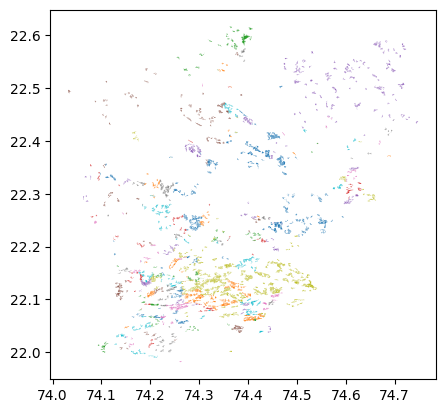

In [44]:
alirajpur_khasra_gdf.plot(column="Tehsil Name")

<Axes: >

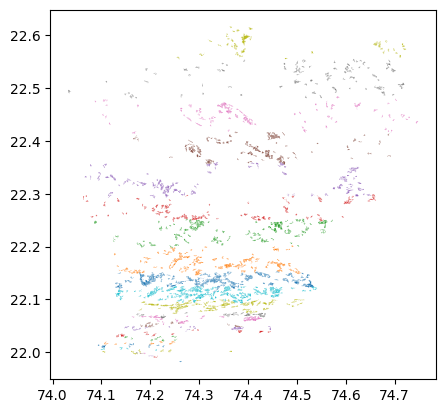

In [43]:
alirajpur_khasra_gdf.plot(column="Patch Name")

#### Add unique ID column (Khasra ID is not unique across the dataset)

In [45]:
alirajpur_khasra_gdf["Khasra ID"].duplicated().sum()

16104

In [47]:
alirajpur_khasra_gdf["Khasra ID (Unique)"] = (
    alirajpur_khasra_gdf["Khasra ID"] + " (" + alirajpur_khasra_gdf["Patch Name"] + ")"
)

In [48]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = alirajpur_khasra_gdf[
    alirajpur_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

Number of duplicated Khasra IDs: 1846


In [49]:
duplicated_khasraID_list

array(['1 (ARPR1122)', '1 (ARPR1146)', '1 (ARPR1247)', ...,
       '99 (ARPR382)', '99 (ARPR599)', '991 (ARPR1283)'], dtype=object)

In [50]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / "Alirajpur"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

  0%|          | 0/100 [00:00<?, ?it/s]

In [52]:
# looks like all duplicates are shards of a single real khasra - combine them here
alirajpur_khasra_gdf_dissolved = alirajpur_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [53]:
alirajpur_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

0

In [54]:
alirajpur_khasra_gdf_dissolved[
    alirajpur_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

,Khasra ID (Unique),geometry,Khasra ID,Patch Name,Tehsil Name


#### Load Noiyat allocations and match

In [ ]:
barwani_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Barwani Khasras"
    / "Barvani_20ha_patch_khasra140725_RR.xlsx",
    sheet_name="noiyat_category",
)

In [ ]:
barwani_lookup.columns

In [ ]:
barwani_lookup = barwani_lookup.sort_values(by=["VILLAGEE", "KHASRA_NO"])
barwani_lookup["Category"] = barwani_lookup["Category"].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
barwani_lookup["Khasra ID (Unique)"] = (
    barwani_lookup["KHASRA_NO"].astype(str)
    + " ("
    + barwani_lookup["patch_name"].astype(str)
    + ")"
)

In [ ]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = barwani_lookup.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

In [ ]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_dissolved.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

barwani_khasra_gdf_merged

In [ ]:
deduped_barwani_lookup = barwani_lookup.drop_duplicates(subset=["Khasra ID (Unique)"])[
    ["Khasra ID (Unique)", "TEHSILCODE", "VILLAGEE", "BHUCODE", "noiyat", "ROR_kid"]
]
deduped_barwani_lookup.rename(
    columns={
        "TEHSILCODE": "Tehsil Code",
        "VILLAGEE": "Village Name",
        "BHUCODE": "BHU Code",
        "noiyat": "Noiyat",
        "ROR_kid": "ROR KID",
    },
    inplace=True,
)

barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.merge(
    deduped_barwani_lookup,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged

In [ ]:
barwani_khasra_gdf_merged.plot(column="Village Name")

In [ ]:
# Calculate original areas
barwani_khasra_gdf_merged["Original Area (ha)"] = (
    barwani_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [ ]:
# add % unusable area
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = (
    barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"]
    / barwani_khasra_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = barwani_khasra_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

In [ ]:
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

#### Cleanup and save

In [59]:
alirajpur_khasra_gdf_merged = alirajpur_khasra_gdf_dissolved.copy()
alirajpur_khasra_gdf_merged["Original Area (ha)"] = (
    alirajpur_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [56]:
alirajpur_khasra_gdf_merged = alirajpur_khasra_gdf_merged.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)

In [61]:
alirajpur_khasra_gdf_merged = alirajpur_khasra_gdf_merged[
    [
        "Khasra ID (Unique)",
        "Tehsil Name",
        # "Village Name",
        # "BHU Code",
        # "Noiyat",
        # "ROR KID",
        "Patch Name",
        "Khasra ID",
        "Original Area (ha)",
        # "Noiyat Unusable Area (ha)",
        # "Noiyat Unusable Area (%)",
        "geometry",
    ]
]

In [62]:
save_shapefiles(
    alirajpur_khasra_gdf_merged,
    PROCESSED_DATA_DIR / "Alirajpur" / "01 Processed Data" / "Cleaned Khasras",
    "alirajpur_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Morena Ravine

In [64]:
alirajpur_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Ravine Khasras" / "Morena_Ravine_land_khasra 020226.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
alirajpur_gdf.geometry = alirajpur_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
alirajpur_gdf = alirajpur_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
alirajpur_gdf = alirajpur_gdf[alirajpur_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

In [ ]:
# no info in Description
alirajpur_gdf.drop(columns=["Description"], inplace=True)

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [ ]:
# the Name column has names like 30.444 ARPR516 for patches and others are khasras
# separate those that have ARPR in the name
alirajpur_patches_gdf = alirajpur_gdf[alirajpur_gdf["Name"].str.contains("ARPR")]
alirajpur_patches_gdf["Name"] = alirajpur_patches_gdf["Name"].str.split(" ").str[1]
alirajpur_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
alirajpur_patches_gdf

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_96770/1195661368.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alirajpur_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)


,Patch Name,geometry
1448,ARPR12,"POLYGON ((74.26319 21.98347, 74.26318 21.98346..."
1450,ARPR25,"POLYGON ((74.21429 21.99081, 74.21433 21.99084..."
1452,ARPR26,"POLYGON ((74.20598 21.99324, 74.20634 21.99330..."
1454,ARPR34,"POLYGON ((74.18137 21.99831, 74.18122 21.99836..."
1456,ARPR36,"POLYGON ((74.18796 21.99879, 74.18797 21.99883..."
...,...,...
3528,ARPR4670,"POLYGON ((74.39228 22.60282, 74.39206 22.60283..."
3530,ARPR4678,"POLYGON ((74.36996 22.60826, 74.36990 22.60832..."
3532,ARPR4680,"POLYGON ((74.38114 22.61072, 74.38106 22.61080..."
3534,ARPR4682,"POLYGON ((74.40302 22.61474, 74.40299 22.61475..."


In [ ]:
# get tehsils
alirajpur_tehsil_gdf = alirajpur_gdf[
    ~ alirajpur_gdf["Name"].str.contains(r"\d", na=False)
    & alirajpur_gdf["Name"].notna()
    & (alirajpur_gdf["Name"].str.strip() != "")
]
alirajpur_tehsil_gdf.rename(columns={"Name": "Tehsil Name"}, inplace=True)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_96770/2024228106.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alirajpur_tehsil_gdf.rename(columns={"Name": "Tehsil Name"}, inplace=True)


In [ ]:
# khasras - drop any rows which match ARPR somewhere, contain no numbers, or are blank in Name
alirajpur_khasra_gdf = alirajpur_gdf[
    ~alirajpur_gdf["Name"].str.contains("ARPR", case=False, na=False)
    & alirajpur_gdf["Name"].str.contains(r"\d", na=False)
    & alirajpur_gdf["Name"].notna()
    & (alirajpur_gdf["Name"].str.strip() != "")
]
alirajpur_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
alirajpur_khasra_gdf

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_96770/548506478.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alirajpur_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)


,Khasra ID,geometry
3538,27,"POLYGON ((74.26319 21.98347, 74.26318 21.98346..."
3540,236,"POLYGON ((74.20688 21.99098, 74.20689 21.99102..."
3542,237,"POLYGON ((74.20684 21.99057, 74.20684 21.99083..."
3544,410,"POLYGON ((74.21165 21.99065, 74.21155 21.99074..."
3546,363,"POLYGON ((74.20857 21.99091, 74.20838 21.99092..."
...,...,...
40754,410,"POLYGON ((74.29367 22.13049, 74.29368 22.13051..."
40756,411,"POLYGON ((74.29367 22.13049, 74.29368 22.13051..."
40758,341,"POLYGON ((74.27482 22.17989, 74.27482 22.17990..."
40760,1,"POLYGON ((74.27482 22.17989, 74.27482 22.17990..."


In [ ]:
len(alirajpur_khasra_gdf) + len(alirajpur_patches_gdf) + len(
    alirajpur_gdf[~alirajpur_gdf["Name"].str.contains(r"\d", na=False)]
) == len(alirajpur_gdf)

True

In [ ]:
# add in Patch Name
alirajpur_khasra_gdf = alirajpur_khasra_gdf.sjoin(
    alirajpur_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
alirajpur_khasra_gdf = alirajpur_khasra_gdf[
    ~alirajpur_khasra_gdf.index.duplicated(keep="first")
]

# add in Tehsil Name
alirajpur_khasra_gdf = alirajpur_khasra_gdf.sjoin(
    alirajpur_tehsil_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
alirajpur_khasra_gdf = alirajpur_khasra_gdf[
    ~alirajpur_khasra_gdf.index.duplicated(keep="first")
]

In [ ]:
alirajpur_khasra_gdf

,Khasra ID,geometry,Patch Name,Tehsil Name
3538,27,"POLYGON ((74.26319 21.98347, 74.26318 21.98346...",ARPR12,Khundi
3540,236,"POLYGON ((74.20688 21.99098, 74.20689 21.99102...",ARPR25,Wakner
3542,237,"POLYGON ((74.20684 21.99057, 74.20684 21.99083...",ARPR25,Wakner
3544,410,"POLYGON ((74.21165 21.99065, 74.21155 21.99074...",ARPR25,Wakner
3546,363,"POLYGON ((74.20857 21.99091, 74.20838 21.99092...",ARPR25,Wakner
...,...,...,...,...
40754,410,"POLYGON ((74.29367 22.13049, 74.29368 22.13051...",ARPR1074,Silota
40756,411,"POLYGON ((74.29367 22.13049, 74.29368 22.13051...",ARPR1074,Silota
40758,341,"POLYGON ((74.27482 22.17989, 74.27482 22.17990...",ARPR1567,Athawa
40760,1,"POLYGON ((74.27482 22.17989, 74.27482 22.17990...",ARPR1567,Athawa


In [ ]:
print(alirajpur_khasra_gdf["Patch Name"].isnull().sum(), alirajpur_khasra_gdf["Tehsil Name"].isnull().sum())


0 0


<Axes: >

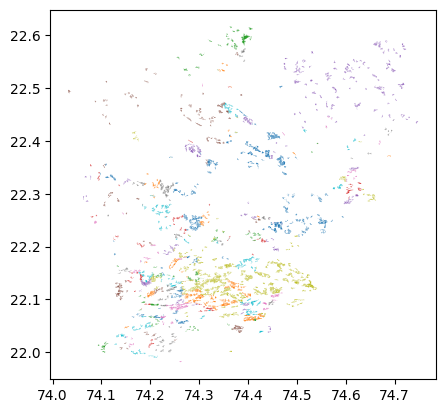

In [ ]:
alirajpur_khasra_gdf.plot(column="Tehsil Name")

<Axes: >

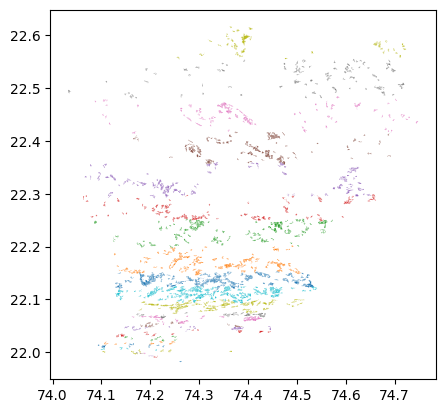

In [ ]:
alirajpur_khasra_gdf.plot(column="Patch Name")

#### Add unique ID column (Khasra ID is not unique across the dataset)

In [ ]:
alirajpur_khasra_gdf["Khasra ID"].duplicated().sum()

16104

In [ ]:
alirajpur_khasra_gdf["Khasra ID (Unique)"] = (
    alirajpur_khasra_gdf["Khasra ID"] + " (" + alirajpur_khasra_gdf["Patch Name"] + ")"
)

In [ ]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = alirajpur_khasra_gdf[
    alirajpur_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

Number of duplicated Khasra IDs: 1846


In [ ]:
duplicated_khasraID_list

array(['1 (ARPR1122)', '1 (ARPR1146)', '1 (ARPR1247)', ...,
       '99 (ARPR382)', '99 (ARPR599)', '991 (ARPR1283)'], dtype=object)

In [ ]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / "Alirajpur"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
# looks like all duplicates are shards of a single real khasra - combine them here
alirajpur_khasra_gdf_dissolved = alirajpur_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [ ]:
alirajpur_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

0

In [ ]:
alirajpur_khasra_gdf_dissolved[
    alirajpur_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

,Khasra ID (Unique),geometry,Khasra ID,Patch Name,Tehsil Name


#### Load Noiyat allocations and match

In [ ]:
barwani_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Barwani Khasras"
    / "Barvani_20ha_patch_khasra140725_RR.xlsx",
    sheet_name="noiyat_category",
)

In [ ]:
barwani_lookup.columns

In [ ]:
barwani_lookup = barwani_lookup.sort_values(by=["VILLAGEE", "KHASRA_NO"])
barwani_lookup["Category"] = barwani_lookup["Category"].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
barwani_lookup["Khasra ID (Unique)"] = (
    barwani_lookup["KHASRA_NO"].astype(str)
    + " ("
    + barwani_lookup["patch_name"].astype(str)
    + ")"
)

In [ ]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = barwani_lookup.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

In [ ]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_dissolved.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

barwani_khasra_gdf_merged

In [ ]:
deduped_barwani_lookup = barwani_lookup.drop_duplicates(subset=["Khasra ID (Unique)"])[
    ["Khasra ID (Unique)", "TEHSILCODE", "VILLAGEE", "BHUCODE", "noiyat", "ROR_kid"]
]
deduped_barwani_lookup.rename(
    columns={
        "TEHSILCODE": "Tehsil Code",
        "VILLAGEE": "Village Name",
        "BHUCODE": "BHU Code",
        "noiyat": "Noiyat",
        "ROR_kid": "ROR KID",
    },
    inplace=True,
)

barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.merge(
    deduped_barwani_lookup,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged

In [ ]:
barwani_khasra_gdf_merged.plot(column="Village Name")

In [ ]:
# Calculate original areas
barwani_khasra_gdf_merged["Original Area (ha)"] = (
    barwani_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [ ]:
# add % unusable area
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = (
    barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"]
    / barwani_khasra_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = barwani_khasra_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

In [ ]:
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

#### Cleanup and save

In [ ]:
alirajpur_khasra_gdf_merged = alirajpur_khasra_gdf_dissolved.copy()
alirajpur_khasra_gdf_merged["Original Area (ha)"] = (
    alirajpur_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [ ]:
alirajpur_khasra_gdf_merged = alirajpur_khasra_gdf_merged.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)

In [ ]:
alirajpur_khasra_gdf_merged = alirajpur_khasra_gdf_merged[
    [
        "Khasra ID (Unique)",
        "Tehsil Name",
        # "Village Name",
        # "BHU Code",
        # "Noiyat",
        # "ROR KID",
        "Patch Name",
        "Khasra ID",
        "Original Area (ha)",
        # "Noiyat Unusable Area (ha)",
        # "Noiyat Unusable Area (%)",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    alirajpur_khasra_gdf_merged,
    PROCESSED_DATA_DIR / "Alirajpur" / "01 Processed Data" / "Cleaned Khasras",
    "alirajpur_cleaned_khasras",
    formats=["kml", "parquet"],
)